# Workflow management

Data scientists, as expected, often concentrate on data and models. However, actually running this model and preparing the data to feed it becomes the central task in "production." This is when the effort of data scientists is leveraged to provide value to downstream clients. We call this process "workflow management."

This lecture will break workflow managment into two primary components:
1. Scheduling of jobs
2. Management of pipelines

## Scheduling of jobs
Once you have developed a model, "automating" it or "deploying" it seems like a simple process: convert this model to an independently running script, then schedule the script to run in the early morning (or late evening), every day.

### Simple, time based, jobs with `cron`
Perhaps the oldest and simplest way to schedule jobs is via a simple unix utility called `cron`. This tool exists in every Linux and Mac (Windows has its own version, called "Task Scheduler"). Here is a sample scritp:
```cron
# Download input file A every day at 1 am
0 1 * * * curl -o /ml_system/data/data_a.csv https://example.com/data_a.csv

# Download input file B every day at 1:05 am
5 1 * * * curl -o /ml_system/data/data_b.csv https://example.com/data_b.csv

# Run the model every day at 1:10 am
10 1 * * * /ml_system/run_model.sh ../data/data_a.csv ../data/data_b.csv > ../output/predictions.csv
```

The syntax may seem strange but is quote popular and is even used in more modern tools:
```
*     *     *     *     *     command-to-execute
|     |     |     |     |
|     |     |     |     +-- Day of the Week (0-6, Sunday=0 or Sunday=7)
|     |     |     +-- Month (1-12 or JAN-DEC)
|     |     +-- Day of the Month (1-31)
|     +-- Hour (0-23)
+-- Minute (0-59)
```

Notice that `cron` only allows us to schedule jobs based on time. It has no useful features, such as:
- Monitoring whether the job succeeded or failed
- Track history of runs
- The jobs can be temporarily paused only by editing the `crontab` file
- You cannot condition the execution of one job on the success or failure of another job
- No native ability to manage scenarios where a job fails (e.g., retry logic, alerting)

As always, this presents a useful case of trade-offs. `cron` requires no installation, it is universally available and has decades of community support. Such simplicity may be worth the cost of missing features.

#### Local `cron` experimentation
If you are on a Mac or Linux, you can experiment with your local version of cron. The configuration file which contains `cron` jobs is called the `crontab`.
You can view the contents of your `conrtab` via the command `crontab -l` command - initially there will be no entries. You edit the `crontab` via `crontab -e` (note that this will start the `vim` editor - you exit it by the command `:q`

### Management of pipelines
One obvious missing feature of `cron` jobs is the lack of dependency management. For example, in the above example, what if downloading `data_a.csv` fails? The model will still run, but it will run with incomplete data. This may lead to garbage predictions. But there are more complex definitions of dependencies:
- Kick off a job dependent on the success or failure of another job
- Kick off a job as soon as a new file appears in a specified directory
- Kick off a job only if multiple upstream jobs have completed successfully

In fact, the idea of dependency management can be generalized to the idea of "pipelines." The need for pipelines shows up even when a solo data scientist in the development stage of their model. They may have notebooks such as the following:
```bash
data_preparation.ipynb
feature_engineering.ipynb
model_training.ipynb
model_evaluation.ipynb
```
Notebooks are often not organize as well as displayed above, but it should be obvious that there is an order and an implicit dependency among them. Obviously `data_preparation.ipynb` mus tbe run before `feature-engineering.ipynb`, which should be run before `model_training.ipynb`, and so on.

The `cron` system, shown above, has no ability to manage such dependencies. Surprisingly, the Jupyter project also includes no such ability. 

Here is a sample "zone" from Dataiku (a commercial product):

<div>
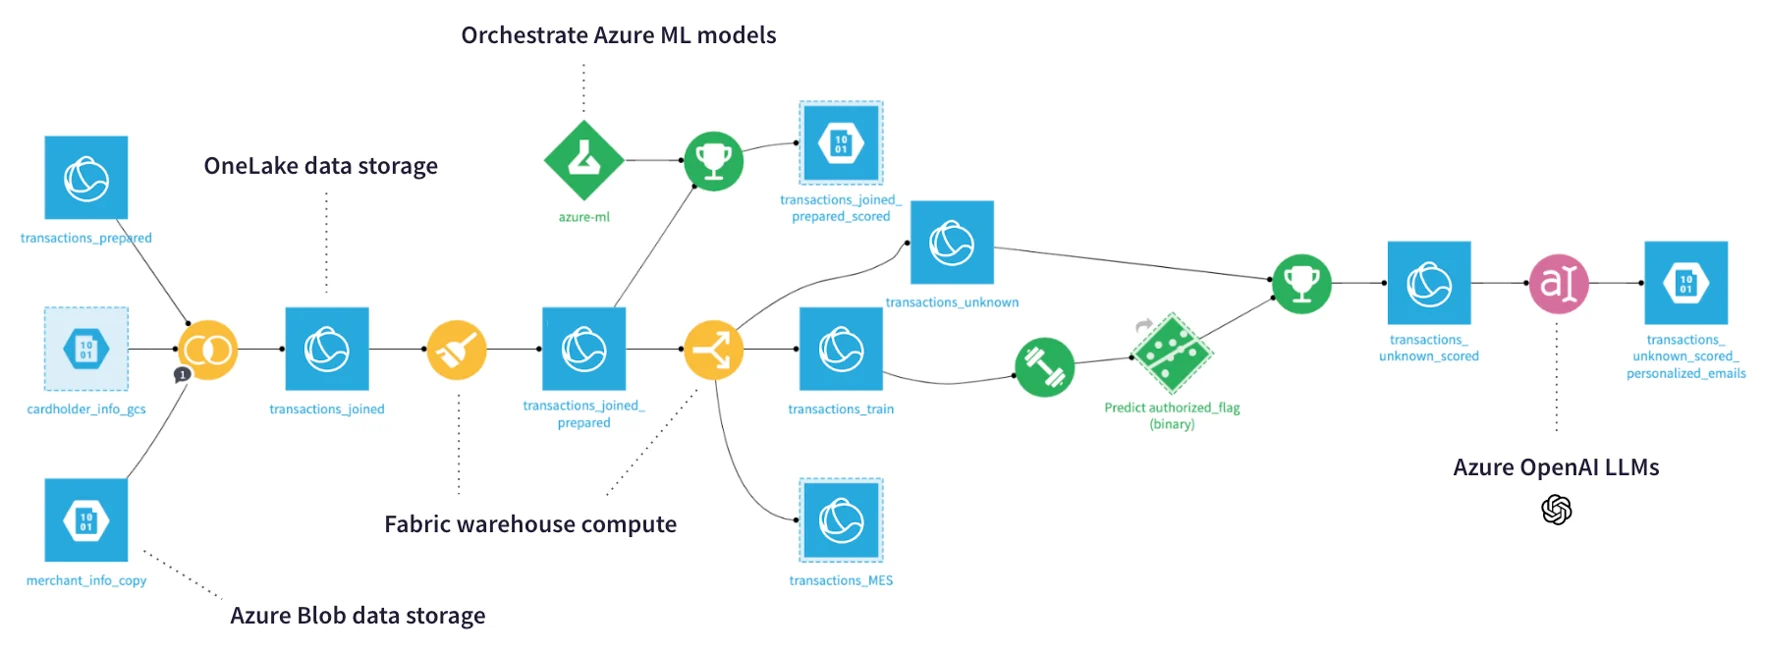
</div>

Source: https://www.dataiku.com/stories/blog/i-have-microsoft-why-do-i-need-dataiku

### Historical notes on dependency management

#### Makefiles
The idea of dependency management is not new. In fact, the oldest and most widely used build system is `make` and it was introduced back in 1976. Although it is widely regarded is being difficult to understand (at first sight), it continues to be widely used, to this day. In fact, the "Cookie Cutter Data Science" project (https://drivendata.github.io/cookiecutter-data-science/) includes a `Makefile` to manage dependencies among various steps in a data science project. Here is a sample `Makefile` from that project:
```makefile
...
format:
	isort --profile black ccds hooks tests docs/scripts
	black ccds hooks tests docs/scripts

lint:
	flake8 ccds hooks tests docs/scripts
	isort --check --profile black ccds hooks tests docs/scripts
	black --check ccds hooks tests docs/scripts

clean: clean-build clean-pyc clean-test ## remove all build, test, coverage and Python artifacts

clean-build: ## remove build artifacts
	rm -fr build/
	rm -fr dist/
	rm -fr .eggs/
	find . -name '*.egg-info' -exec rm -fr {} +
	find . -name '*.egg' -exec rm -f {} +

...

dist: clean ## builds source and wheel package
	python -m build
	ls -l dist
...
```
Notice that tasks are grouped by a label and some labels, such as `dist` and `clean` depend on other labels. For example, `dist` depends on `clean`. Such files have a specific name: `Makefile`. Tasks are executed by ivoking commands such as `make clean` or `make dist`.

#### Ant
In 2000s, with the popularity of Java (and XML), a tool called "Ant" gained popularity. It also allowed tasks to be defined, with dependency attributes:
```xml
<?xml version="1.0"?>
<project name="Hello" default="compile">
    <target name="clean" description="remove intermediate files">
        <delete dir="classes"/>
    </target>
    <target name="clobber" depends="clean" description="remove all artifact files">
        <delete file="hello.jar"/>
    </target>
    <target name="compile" description="compile the Java source code to class files">
        <mkdir dir="classes"/>
        <javac srcdir="." destdir="classes"/>
    </target>
    <target name="jar" depends="compile" description="create a Jar file for the application">
        <jar destfile="hello.jar">
            <fileset dir="classes" includes="**/*.class"/>
            <manifest>
                <attribute name="Main-Class" value="HelloProgram"/>
            </manifest>
        </jar>
    </target>
</project>
```

#### Web app ecosystm tools: package.json, grunt, gulp, webpack, vite
As with all things related to web app development, there is a cambrian explosion of tools and competitors to those tools showing up almost on a monthly basis. 

#### All of these tools organize dependencies as DAGs
Students of dependency management system must learn the term DAGs or "Directed, acyclic graphs." A "Graph" is a data structure in computer science, similar to lists, arrays and dictionaries. A graph is simply a collection of nodes and connections between those nodes. Think of a map of a country with roads connecting cities. Another example is a social network with people are connected to their friends. A chart showing the CEO of a company, her subordinates and their subordinates is also a graph. A set of tasks and dependencies among these tasks is also a graph.  

Graph:

<div>
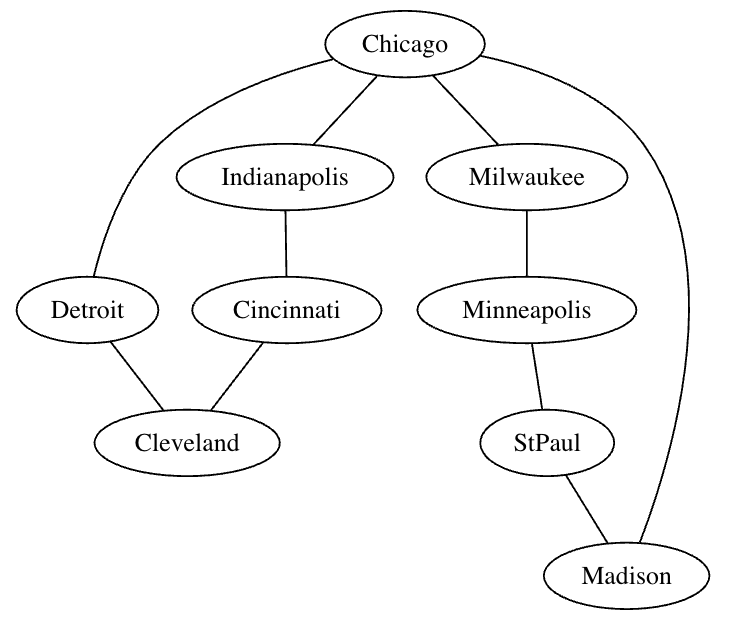
</div>

Directed graph: 
<div>
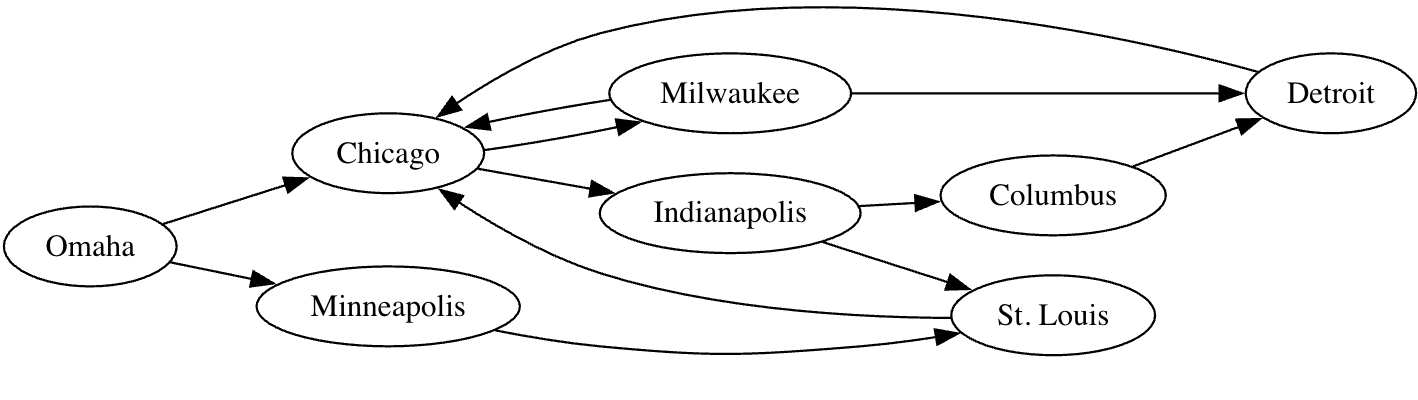
</div>

Directed graph with no cycles (DAG):

<div>
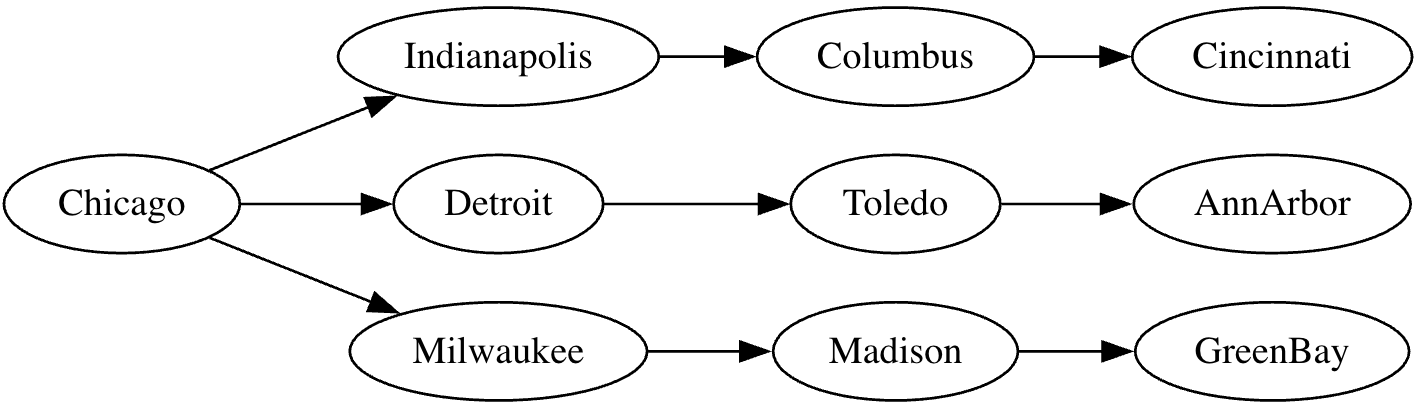
</div>

Limiting your pipelines to DAGs has several advantages:
1. No cycles means that you **cannot have infinite loops** in your dependencies. For example, if task A depends on task B, and task B depends on task A, neither can ever be executed.
2. DAGs can be topologically sorted. This means that there is a well-defined order in which tasks can be executed. This is crucial for **ensuring that all dependencies are met before a task is executed**.
3. DAGs are **easier to visualize and understand**. The absence of cycles makes it easier to trace the flow of dependencies and identify potential bottlenecks or issues in the pipeline.
4. DAGs can either be executed from the end (**execute all dependencies required to execute this node**) **or** from the beginning (**execute all nodes downstream of this node**).


### Adding "state" or "memory" to DAGS
Allowing nodes to "remember" when they were last run, whether they succeeded or failed, and other metadata can greatly enhance the functionality of DAG-based workflow management systems. Some benefits of such systems:
- If a node remembers when it was last run, it doesn't have to be executed again. For example, you don't have to download a big file if you already did so.
- If a node remembers the number of times it has failed, we can add policies defining how many re-tries are allowed (to keep upstream systems from being overwhelmed).

### Modern workflow management systems: Airflow and Dagster
As of 2026, the two most popular workflow management systems are Apache Airflow and Dagster. Both are open-source tools that provide robust features for managing complex data pipelines. Apache Airflow, originally developed by Airbnb, has become a widely adopted solution for orchestrating workflows. Airflow focuses on tasks defined as code, allowing users to create, schedule, and monitor workflows programmatically. 

Dagster, on the other hand, emphasizes data-centric workflows. Users of this software define assets and their transformations. 

Both tools offer features such as:
- DAG-based workflow management
- Scheduling and monitoring of jobs
- Retry policies and alerting mechanisms
- Integration with various data sources and processing frameworks
- Python based task/schedule definitions

In this class, we will focus on Dagster, since it is slighty easier to set up and use.

## `dagster` workshop

### Install `dagster`
Since `dagsters` is a Python packages, you can install it via `pip`:
```bash
pip install dagster dagster-webserver dagster-dg-cli requests pandas
```
(the _pandas_ and _requests_ packages are needed for our example code below)



### Create a Python script containing tasks and dependencies
The code will download information about Chicago's divvy bike stations every 5 minutes, transform the data into a CSV file and save it to `data` directory.

Code for divvy_pipeline.py:

```python
import requests
import pandas as pd
from dagster import asset, Definitions, ScheduleDefinition
from datetime import datetime

@asset
def station_status_raw():
    """Fetch raw station status from Divvy API"""
    response = requests.get("https://gbfs.lyft.com/gbfs/2.3/chi/en/station_status.json")
    response.raise_for_status()
    return response.json()

@asset
def station_status_csv(station_status_raw):
    """Transform JSON to CSV format"""
    stations = station_status_raw['data']['stations']
    df = pd.DataFrame(stations)
    df['last_updated'] = datetime.fromtimestamp(station_status_raw['last_updated'])
    
    # Save to CSV
    output_path = f"data/divvy_stations_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    df.to_csv(output_path, index=False)
    return output_path

# Schedule to run every 5 minutes
station_schedule = ScheduleDefinition(
    job=Definitions.define_asset_job("station_job", selection="*"),
    cron_schedule="*/5 * * * *"
)

defs = Definitions(
    assets=[station_status_raw, station_status_csv],
    schedules=[station_schedule]
)
```


### Kick off these jobs and the admin app
```bash
dagster dev -f divvy_pipeline.py
```

Follow the instructions to open the Dagster web app in your browser. You should see the assets and be able to manually trigger runs or wait for the scheduled runs to occur.

<div>
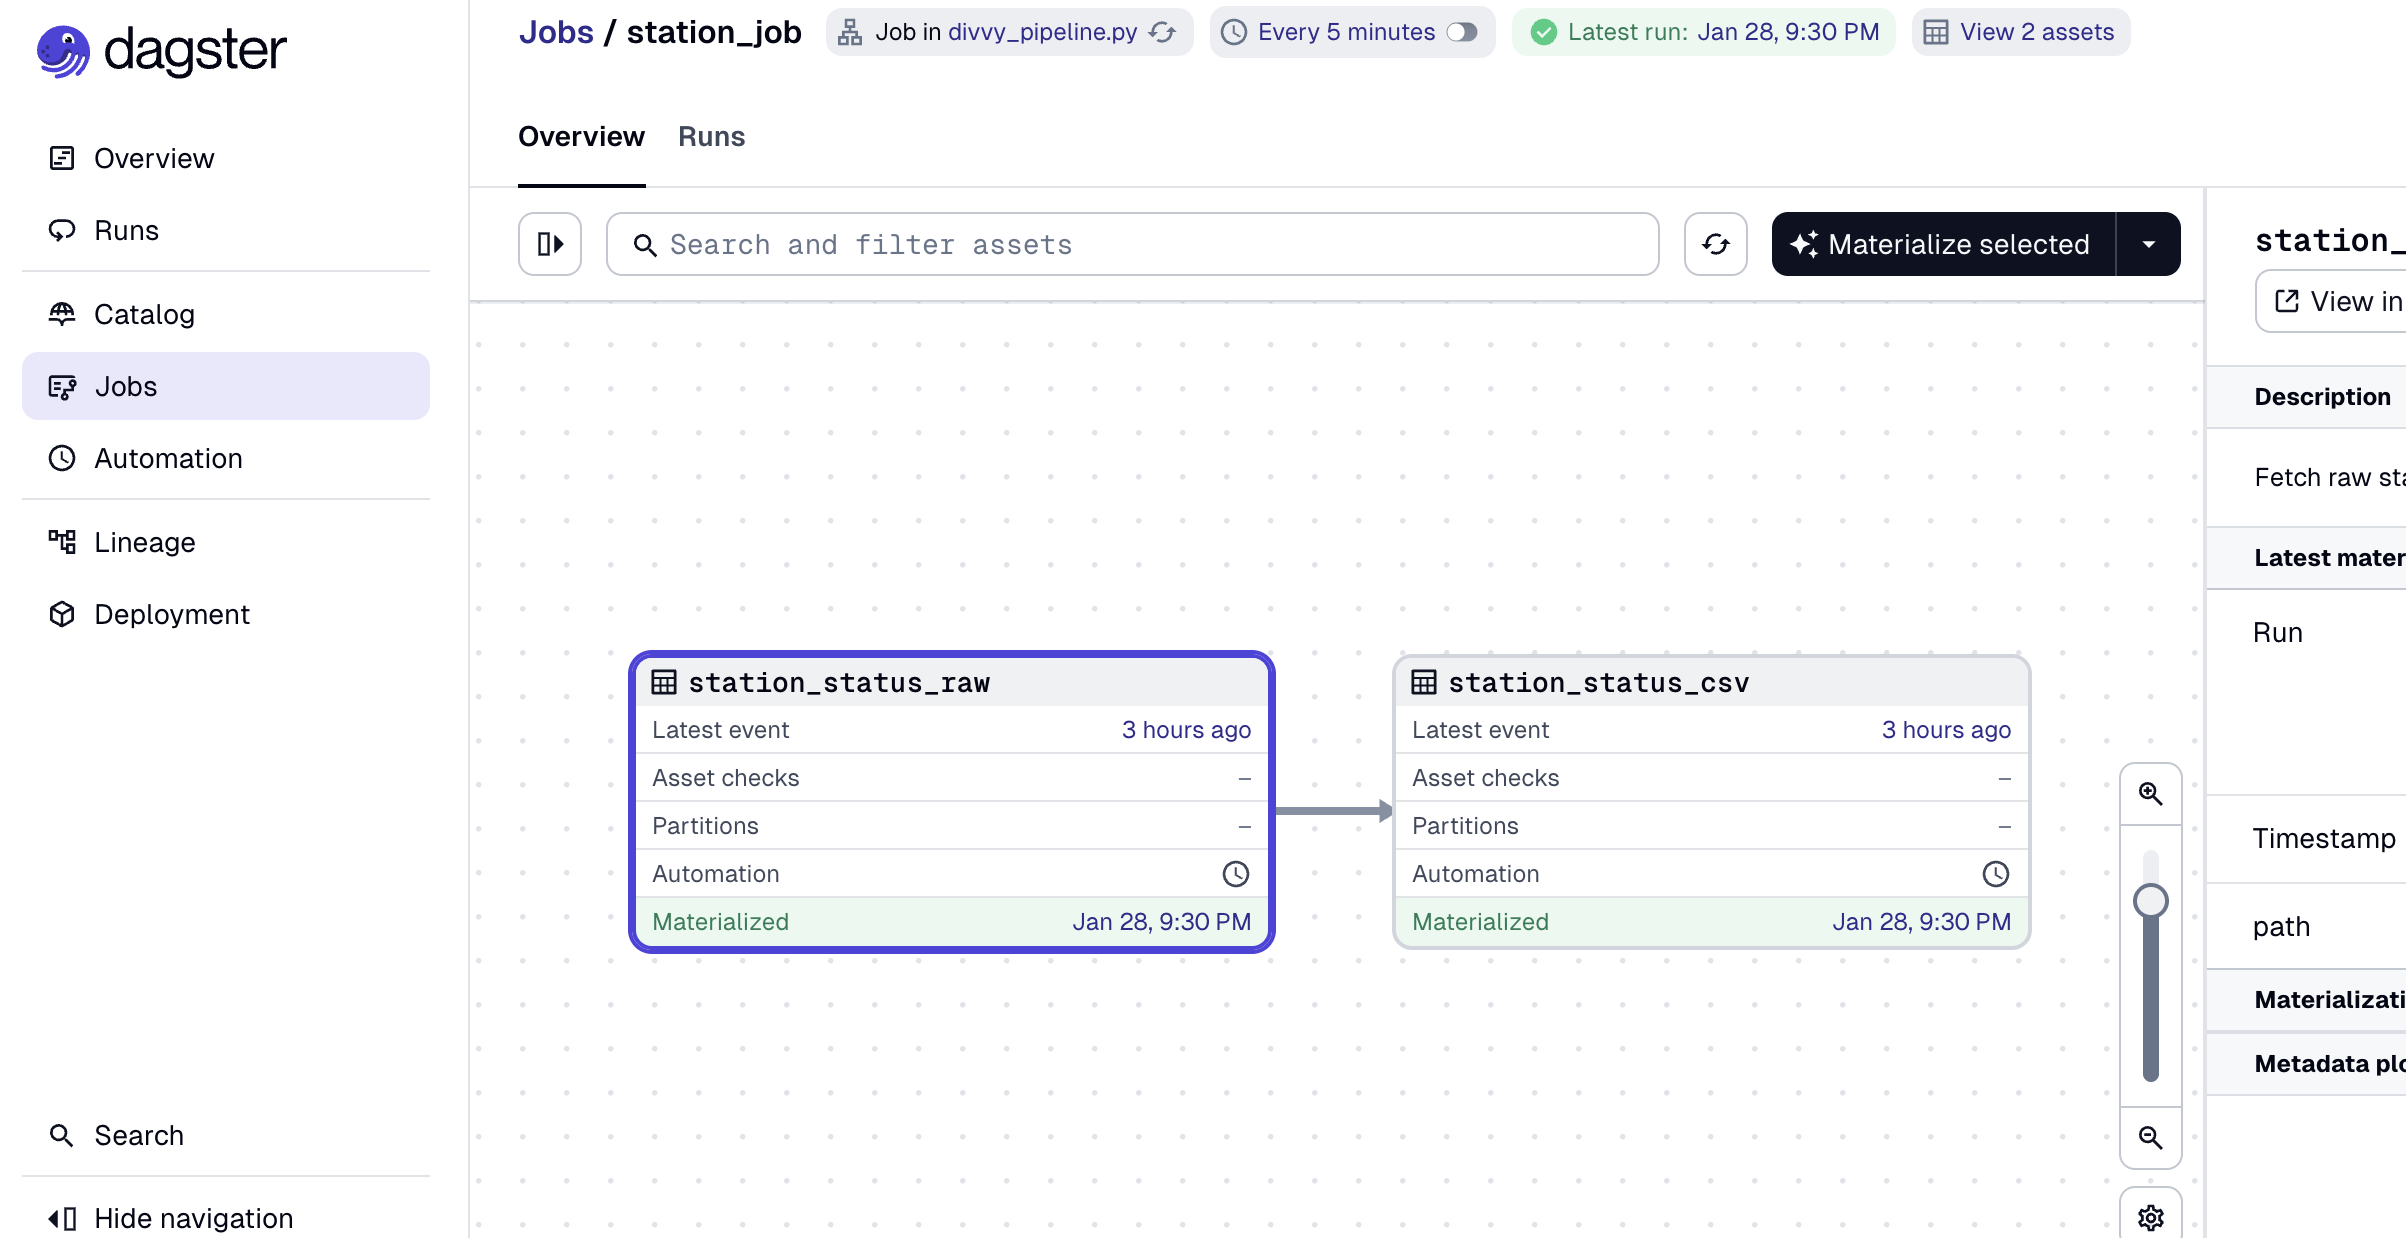
</div>

## WARNING: be good internet citizens

Please note that when you request data from a remote server, either a web page or a file, you are placing a load on the remote server. The remote server will have the following costs:
1. The cost of bandwidth - transferring data is not always free
2. Similarly, the bandwidth used to transfer data to you diminishes their ability to deliver data to other clients
3. The cost of cpu - if their cpu is working to respond to your request, their ability to respond to other requests is diminished
4. The cost of electricity - cpu work is correlated with electricity usage

These costs are generally infinitesimally small for small loads, which as web pages, small pictures, small csv files, etc. However, if you are downloading larger files or downloading from non-profit, academic, personal or small-business sites, the load may be significant.

You should follow some common best practices:  
1. Don't repeatedly request the same file. If you downloaded it, cache is somewhere and avoid downloading the file again.
2. Deliberately slow the request time: if you are downloading a large number of smaller files, don't try to download thousands at the same time. Often site contracts will liimt the number of request per minutes. Respect those limits.